## Welcome back to Python Notebooks!

Didja miss me??

### And welcome to Week 4, Day 2 - introducing LangGraph!

In [2]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

In [3]:
# Some useful constants

nouns = ["Cabbages", "Unicorns", "Toasters", "Penguins", "Bananas", "Zombies", "Rainbows", "Eels", "Pickles", "Muffins"]
adjectives = ["outrageous", "smelly", "pedantic", "existential", "moody", "sparkly", "untrustworthy", "sarcastic", "squishy", "haunted"]

In [4]:
# Our favorite first step! Crew was doing this for us, by the way.
load_dotenv(override=True)


True

In [6]:
def shout(text: Annotated[str, "something to be shouted"]) -> str:
    print(text.upper())
    return text.upper()

shout('Niggs')

NIGGS


'NIGGS'

### A word about "Annotated"

You probably know this; type hinting is a feature in Python that lets you specify the type of something:

`my_favorite_things: List`

But you may not know this:

You can also use something called "Annotated" to add extra information that somebody else might find useful:

`my_favorite_things: Annotated[List, "these are a few of mine"]`

LangGraph needs us to use this feature when we define our State object.

It wants us to tell it what function it should call to update the State with a new value.

This function is called a **reducer**.

LangGraph provides a default reducer called `add_messages` which takes care of the most common case.

And that hopefully explains why the State looks like this.




### Step 1: Define the State object

You can use any python object; but it's most common to use a TypedDict or a Pydantic BaseModel.

In [7]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

### Step 2: Start the Graph Builder with this State class

In [8]:
graph_builder = StateGraph(State)

### Step 3: Create a Node

A node can be any python function.

The reducer that we set before gets automatically called to combine this response with previous responses


In [9]:
def our_first_node(old_state: State) -> State:
    reply = f'{random.choice(nouns)} are {random.choice(adjectives)}'
    messages = [{"role": "assistant", "content": reply}]

    new_state = State(messages=messages)
    return new_state

graph_builder.add_node("first_node", our_first_node)

### Step 4: Create Edges

In [10]:
graph_builder.add_edge(START, "first_node")
graph_builder.add_edge("first_node", END)

### Step 5: Compile the Graph

In [11]:
graph = graph_builder.compile()

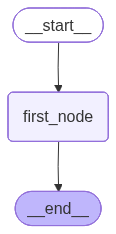

In [12]:
display(Image(graph.get_graph().draw_mermaid_png()))

### That's it! Showtime!

In [ ]:
def chat(user_input: str, history):
    message = {"role": "user", "content": user_input}
    messages = [message]
    state = State(messages=messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='Hey bro', additional_kwargs={}, response_metadata={}, id='6489f60a-2388-4ed0-be15-87d5392dc5bb'), AIMessage(content='Cabbages are squishy', additional_kwargs={}, response_metadata={}, id='3247a19e-b275-4879-b7e1-0b812029ada0')]}
{'messages': [HumanMessage(content='What the fuck?', additional_kwargs={}, response_metadata={}, id='27da0ad8-efa2-4f62-b974-3b252f7f940b'), AIMessage(content='Muffins are untrustworthy', additional_kwargs={}, response_metadata={}, id='c682553a-14f7-4754-9f6c-0bea84ac9e7c')]}
{'messages': [HumanMessage(content='Huh?', additional_kwargs={}, response_metadata={}, id='ead1c25f-cd10-4792-90fd-af2b73443535'), AIMessage(content='Eels are squishy', additional_kwargs={}, response_metadata={}, id='26d396bf-01de-484e-b29b-f81dfad99d52')]}
{'messages': [HumanMessage(content="lmao, I don't get you", additional_kwargs={}, response_metadata={}, id='7279f178-fda8-49a3-b29d-62d7d49f17a0'), AIMessage(content='Zombies are sarcastic', additiona

### But why did I show you that?

To make the point that LangGraph is all about python functions - it doesn't need to involve LLMs!!

Now we'll do the 5 steps again, but in 1 shot:

In [14]:
# Step 1: Define the State object
class State(BaseModel):
    messages: Annotated[list, add_messages]


In [15]:
# Step 2: Start the Graph Builder with this State class
graph_builder = StateGraph(State)


In [16]:
# Step 3: Create a Node

llm = ChatOpenAI(model='gpt-4o-mini')

def chatbot_node(old_state: State) -> State:
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state

graph_builder.add_node("chat_bot", chatbot_node)

In [17]:
# Step 4: Create Edges
graph_builder.add_edge(START, "chat_bot")
graph_builder.add_edge("chat_bot", END)

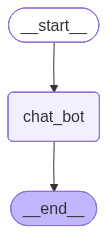

In [18]:
# Step 5: Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### That's it! And, let's do this:

In [ ]:
def chat(user_input: str, history):
    initial_state = State(messages=[{"role": "user", "content": user_input}])
    result = graph.invoke(initial_state)
    print(result)
    return result['messages'][-1].content

gr.ChatInterface(chat, type='messages').launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='My name is Rahul', additional_kwargs={}, response_metadata={}, id='4c729cbd-7626-4009-bef1-fef96acc3436'), AIMessage(content='Nice to meet you, Rahul! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 11, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_11f3029f6b', 'id': 'chatcmpl-CrJfIqNWTbQkwyr4miAi9wCYSjBDP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--a1493308-49ec-488e-9ecb-a23b0387bc9d-0', usage_metadata={'input_tokens': 11, 'output_tokens': 14, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}
{'m